In [ ]:
%matplotlib inline

import random
import math
import time
import os
from os.path import join
import sys
import pandas as pd
pd.set_option('display.max_columns', 500)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy
import bz2

from nltk.tokenize import sent_tokenize

from nltk.tokenize import TweetTokenizer
from nltk.tokenize import RegexpTokenizer
tweet_tokenize = TweetTokenizer().tokenize
regex_tokenize = RegexpTokenizer(r'\w+').tokenize

import matplotlib.colors as mcolors
import pickle

from tqdm.notebook import tqdm_notebook

#import statsmodels as sm
import statsmodels.api as sm
import scipy.stats as st
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn import linear_model
from sklearn import preprocessing

# emotion_columns = ['joy', 'surprise', 'anger', 'sadness', 'fear', 'disgust']
# emotion_columns = ['joy', 'optimism',
#        'anticipation', 'love', 'trust', 'surprise', 'sadness', 'disgust',
#        'fear', 'pessimism', 'anger']

emotions = ['gratitude', 'excitement', 'joy', 'approval', 'admiration', 
    'relief', 'caring', 'optimism', 'realization', 'surprise', 'pride', 
    'desire', 'love', 'annoyance', 'amusement', 'confusion', 'sadness', 
    'curiosity', 'fear', 'disapproval', 'nervousness', 'disgust', 
    'disappointment', 'anger', 'grief', 'remorse', 'embarrassment']

old_emotions = ['gratitude', 'excitement', 'joy', 'approval', 'admiration', 
    'relief', 'caring', 'optimism', 'realization', 'surprise', 'pride', 
    'desire', 'love', 'annoyance', 'amusement', 'confusion', 'sadness', 
    'curiosity', 'fear', 'disapproval', 'nervousness', 'disgust', 
    'disappointment', 'anger', 'grief', 'remorse', 'embarrassment']

dimensions = emotion_columns
dimensions_redux = emotion_columns
dimensions_names = emotion_columns
dimensions_names_redux = emotion_columns
dims2name = {'joy':'joy', 'optimism':'optimism', 'anticipation':'anticipation' , 'love':'love', 'trust':'trust', 'surprise':'surprise', 
             'sadness':'sadness', 'disgust':'disgust', 'fear':'fear', 'pessimism':'pessimism', 'anger':'anger'}

def ci(x, confidence=0.95):
    avg = np.mean(x)
    low, high = st.t.interval(confidence, len(x)-1, loc=avg, scale=st.sem(x))
    return (avg, high-avg)
    
#dimension-dependent weights
def standardized_dimension_score(x,mu,std):
    zscore = (x-mu)/std
    if zscore >= 0:
        return 1/(1+zscore)
    else:
        zscore = -zscore
        return 2 - (1/(1+zscore))

In [2]:
positive_emotions = ["joy", "optimism", "love"]
negative_emotions = ["sadness", "disgust", "fear", "pessimism", "anger"]
ambiguous_emotions = ["anticipation", "trust", "surprise"]

In [3]:
D = pd.read_csv("../data/paragraph_turns_new_emotions.csv")

In [4]:
# D = pd.read_csv("../data/paragraph_turns_ekman.csv")
# D.drop(columns=[col for col in old_emotions if col in D.columns], inplace=True)
# for emotion in emotion_columns:
#     D[emotion] = (D['ekman'] == emotion).astype(int)

In [5]:
for column in emotion_columns:
    D[f'{column}_weighted'] = D[column].copy()

In [6]:
D['number_of_words'] = D['sentence'].apply(lambda x: len(str(x).split()))
D['log_number_of_words'] = D['number_of_words'].apply(lambda x: np.log(x) if x > 0 else 0)

In [7]:
threshold = 0.85
for column in emotion_columns:
    D[f'{column}'] = (D[column] >= threshold).astype(int)

In [8]:
df = D[['collectiveAction'] + ['problem_solution'] + ['call_to_action'] + ['intention'] + ['execution'] + emotion_columns + [f'{col}_weighted' for col in emotion_columns] + ['log_number_of_words']]

In [9]:
# df = D[['collectiveAction'] + emotion_columns + ['log_number_of_words']]

In [10]:
# columns_to_keep = ['collectiveAction'] + [col for col in D.columns if col.endswith('_binarized')]
# df = D[columns_to_keep]

In [11]:
# group_a = ['collectiveAction', 'problem_solution', 'call_to_action', 'intention', 'execution']
# group_b = emotion_columns  

# all_combinations = {(0,0), (0,1), (1,0), (1,1)}

# # Check each pair of (group_a, group_b) columns
# for col_a in group_a:
#     for col_b in group_b:
#         # Create a set of observed (col_a, col_b) value pairs
#         observed_combinations = set(zip(df[col_a], df[col_b]))

#         # Determine which combinations are missing
#         missing = all_combinations - observed_combinations
        
#         if missing:
#             print(f"{col_a} & {col_b} is missing: {sorted(missing)}")

In [12]:
#df_comments.head()

#### Comments delta vs. non-delta

In [13]:
#df['noemotions'] = df[[f'{d}' for d in dimensions_names_redux]].sum(axis=1)
#df['noemotions'] = df['noemotions'].apply(lambda x : 0 if x>0 else 1)
#log_lengths = df[df['noemotions'] == 1]['log_number_of_words']
#avg = np.mean(log_lengths)
#stdev = np.std(log_lengths)
#df[f'noemotions_weighted'] = df['log_number_of_words'].apply(lambda x: standardized_dimension_score(x,avg,stdev)) * df['noemotions']

delta = collective action

In [14]:
# df_no_delta = df[df['collectiveAction'] == 0].dropna()
# df_delta = df[df['collectiveAction'] == 1].dropna()
# # df_delta = df_delta[df_delta['is_op'] == False]
# # df_no_delta = df_no_delta[df_no_delta['is_op'] == False]

In [15]:
df.columns

Index(['collectiveAction', 'problem_solution', 'call_to_action', 'intention',
       'execution', 'joy', 'optimism', 'anticipation', 'love', 'trust',
       'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger',
       'joy_weighted', 'optimism_weighted', 'anticipation_weighted',
       'love_weighted', 'trust_weighted', 'surprise_weighted',
       'sadness_weighted', 'disgust_weighted', 'fear_weighted',
       'pessimism_weighted', 'anger_weighted', 'log_number_of_words'],
      dtype='object')

In [16]:
# df_no_delta = df[df['collectiveAction'] == 0].dropna()
# df_delta = df[df['collectiveAction'] == 1].dropna()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# y_oddsratio = []
# y_ci_OR = []
# y_ratio = []
# y_delta = []
# y_nodelta = []
# y_ci_delta= []
# y_ci_nodelta = []
# colors = []
# all_dims = dimensions_names_redux 
# for i, dim in enumerate(all_dims):
    
#     print(f'++++++++++++{dim}')
#     scores_delta = df_delta[f'{dim}_weighted'] 
#     scores_no_delta = df_no_delta[f'{dim}_weighted'] 

#     avg_delta, ci_delta = ci(scores_delta)
#     avg_no_delta, ci_no_delta = ci(scores_no_delta)
    
#     print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
#     print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

#     OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) )
#     log_OR = np.log(OR)
#     y_oddsratio.append(OR)
#     y_ratio.append((avg_delta/avg_no_delta)-1)
#     y_delta.append(avg_delta/avg_no_delta)
#     y_nodelta.append(avg_no_delta)
#     y_ci_delta.append(ci_delta/avg_no_delta)
#     y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
#     _dim_delta = int(avg_delta*len(scores_delta))
#     _no_dim_delta = len(scores_delta) - _dim_delta
#     _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
#     _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
#     _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
#     print (f'OR = {OR}')
#     print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    
#     print('>>>', 1/_dim_delta , 1/_no_dim_delta , 1/_dim_no_delta , 1/_no_dim_no_delta)
#     standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
#     print(f'STDERR = {standard_error_log_OR}')
#     ci_log_OR = 1.96 * standard_error_log_OR
#     print(f'CI LOG = {ci_log_OR}')
#     ci_log_OR_upper = log_OR + ci_log_OR
#     ci_log_OR_lower = log_OR - ci_log_OR
#     ci_OR_upper = np.power(np.e,ci_log_OR_upper)
#     ci_OR_lower = np.power(np.e,ci_log_OR_lower)
#     ci_OR = ci_OR_upper - OR
#     y_ci_OR.append(ci_OR)
    
#     print(dim, avg_delta, avg_no_delta, y_ci_OR)
#     if avg_delta > avg_no_delta:
#         clr = '#104076'
#     else:
#         clr = '#BD2B30'  
#     colors.append(clr)

# L = list(zip(y_oddsratio,y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, all_dims))
# L.sort(key=lambda x : x[0], reverse = True)
# labels_ordered = []
# y_ci_nodelta_ordered = []
# for i, l in zip(range(len(L)), L):
#     y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
#     labels_ordered.append(label)
#     y_ci_nodelta_ordered.append(err_nodelta)
    
#     #ax.plot([i], [y_odds], 'o', markersize=1, color=color)
#     ax.scatter([i], [y_odds], s=10, color=color)  
#     #ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')
#     ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
#     #ax.text(i, y_odds + 0.1, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
#     ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# for tick in ax.get_xticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
# for tick in ax.get_yticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
    
# ax.set_xticks(range(len(labels_ordered)))
# ax.set_xticklabels(labels_ordered)
# ax.yaxis.set_ticks_position('right') 
# #ax.set_ylabel(f'Odds ratio (collective action)', size=18)
# ax.axhline(1, linestyle='--', linewidth=1, color='gray')
# for tick in ax.get_xticklabels():
#     tick.set_rotation(90)
# for tick in ax.get_yticklabels():
#     tick.set_rotation(90)
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# #ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.xaxis.set_ticks_position("none")
# #ax.set_xticklabels([])
# plt.tight_layout()
# plt.savefig('../plots/odds_ratio.pdf')

++++++++++++joy
avg. delta : 0.44087178797255483 count delta: 14866
avg. nodelta : 0.27126103715043326 count nodelta: 329229
OR = 2.1182902866024116
#dim-delta=6554, #nodim-delta=8312, #dim-nodelta=89306, #nodim-nodelta=239923
++++++++++++optimism
avg. delta : 0.5848916991793354 count delta: 14866
avg. nodelta : 0.24343238293102976 count nodelta: 329229
OR = 4.379085634560087
#dim-delta=8695, #nodim-delta=6171, #dim-nodelta=80145, #nodim-nodelta=249084
++++++++++++anticipation
avg. delta : 0.1002287098076147 count delta: 14866
avg. nodelta : 0.033350646510483584 count nodelta: 329229
OR = 3.228677861989176
#dim-delta=1490, #nodim-delta=13376, #dim-nodelta=10980, #nodim-nodelta=318249
++++++++++++love
avg. delta : 0.0768868559128212 count delta: 14866
avg. nodelta : 0.02980903869343223 count nodelta: 329229
OR = 2.710855824923776
#dim-delta=1143, #nodim-delta=13723, #dim-nodelta=9814, #nodim-nodelta=319415
++++++++++++trust
avg. delta : 0.0 count delta: 14866
avg. nodelta : 0.0 count no

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_54897/3759414390.py:73: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


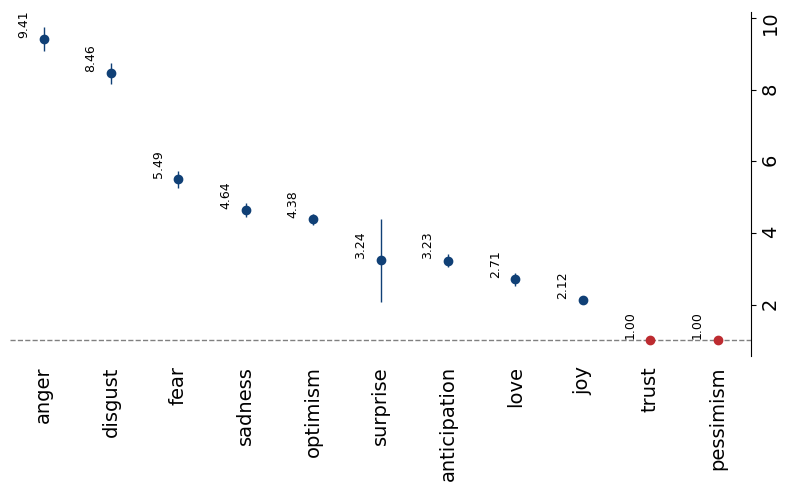

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual list of binary dimensions
dimensions_names_redux = ['joy', 'optimism', 'anticipation', 'love', 'trust',
                          'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger']
all_dims = dimensions_names_redux 

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['collectiveAction'] == 0].dropna()
df_delta = df[df['collectiveAction'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio.pdf')
plt.show()

In [18]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio.csv', index=False)
print(f"Results saved to '../plots/odds_ratio.csv'")

Results saved to '../plots/odds_ratio.csv'


In [19]:
results_df.columns

Index(['emotion', 'odds_ratio', 'lower_ci', 'upper_ci'], dtype='object')

In [20]:
# Map each emotion to a category
def get_category(emotion):
    if emotion in positive_emotions:
        return "positive"
    elif emotion in negative_emotions:
        return "negative"
    elif emotion in ambiguous_emotions:
        return "ambiguous"
    else:
        return "unknown"

# Add a category column
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [21]:
# df_no_delta = df[df['problem_solution'] == 0].dropna()
# df_delta = df[df['problem_solution'] == 1].dropna()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# y_oddsratio = []
# y_ci_OR = []
# y_ratio = []
# y_delta = []
# y_nodelta = []
# y_ci_delta= []
# y_ci_nodelta = []
# colors = []
# all_dims = dimensions_names_redux 
# for i, dim in enumerate(all_dims):
    
#     print(f'++++++++++++{dim}')
#     scores_delta = df_delta[f'{dim}_weighted'] 
#     scores_no_delta = df_no_delta[f'{dim}_weighted'] 

#     avg_delta, ci_delta = ci(scores_delta)
#     avg_no_delta, ci_no_delta = ci(scores_no_delta)
    
#     print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
#     print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

#     OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) )
#     log_OR = np.log(OR)
#     y_oddsratio.append(OR)
#     y_ratio.append((avg_delta/avg_no_delta)-1)
#     y_delta.append(avg_delta/avg_no_delta)
#     y_nodelta.append(avg_no_delta)
#     y_ci_delta.append(ci_delta/avg_no_delta)
#     y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
#     _dim_delta = int(avg_delta*len(scores_delta))
#     _no_dim_delta = len(scores_delta) - _dim_delta
#     _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
#     _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
#     _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
#     print (f'OR = {OR}')
#     print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    
#     print('>>>', 1/_dim_delta , 1/_no_dim_delta , 1/_dim_no_delta , 1/_no_dim_no_delta)
#     standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
#     print(f'STDERR = {standard_error_log_OR}')
#     ci_log_OR = 1.96 * standard_error_log_OR
#     print(f'CI LOG = {ci_log_OR}')
#     ci_log_OR_upper = log_OR + ci_log_OR
#     ci_log_OR_lower = log_OR - ci_log_OR
#     ci_OR_upper = np.power(np.e,ci_log_OR_upper)
#     ci_OR_lower = np.power(np.e,ci_log_OR_lower)
#     ci_OR = ci_OR_upper - OR
#     y_ci_OR.append(ci_OR)
    
#     print(dim, avg_delta, avg_no_delta, y_ci_OR)
#     if avg_delta > avg_no_delta:
#         clr = '#104076'
#     else:
#         clr = '#BD2B30'  
#     colors.append(clr)

# L = list(zip(y_oddsratio,y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, all_dims))
# L.sort(key=lambda x : x[0], reverse = True)
# labels_ordered = []
# y_ci_nodelta_ordered = []
# for i, l in zip(range(len(L)), L):
#     y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
#     labels_ordered.append(label)
#     y_ci_nodelta_ordered.append(err_nodelta)
    
#     #ax.plot([i], [y_odds], 'o', markersize=1, color=color)
#     ax.scatter([i], [y_odds], s=10, color=color)  
#     #ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')
#     ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
#     #ax.text(i, y_odds + 0.1, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
#     ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# for tick in ax.get_xticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
# for tick in ax.get_yticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
    
# ax.set_xticks(range(len(labels_ordered)))
# ax.set_xticklabels(labels_ordered)
# ax.yaxis.set_ticks_position('right') 
# #ax.set_ylabel(f'Odds ratio (problem-solution)', size=18)
# ax.axhline(1, linestyle='--', linewidth=1, color='gray')
# for tick in ax.get_xticklabels():
#     tick.set_rotation(90)
# for tick in ax.get_yticklabels():
#     tick.set_rotation(90)
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# #ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.xaxis.set_ticks_position("none")
# #ax.set_xticklabels([])
# plt.tight_layout()
# plt.savefig('../plots/odds_ratio_problem_solution.pdf')

++++++++++++joy
avg. delta : 0.4145854145854146 count delta: 10010
avg. nodelta : 0.27451397099540537 count nodelta: 334085
OR = 1.8716088150925805
#dim-delta=4150, #nodim-delta=5860, #dim-nodelta=91711, #nodim-nodelta=242374
++++++++++++optimism
avg. delta : 0.5551448551448551 count delta: 10010
avg. nodelta : 0.24928685813490578 count nodelta: 334085
OR = 3.758048115721676
#dim-delta=5557, #nodim-delta=4453, #dim-nodelta=83283, #nodim-nodelta=250802
++++++++++++anticipation
avg. delta : 0.0952047952047952 count delta: 10010
avg. nodelta : 0.034473262792403134 count nodelta: 334085
OR = 2.947069973100908
#dim-delta=953, #nodim-delta=9057, #dim-nodelta=11517, #nodim-nodelta=322568
++++++++++++love
avg. delta : 0.07092907092907093 count delta: 10010
avg. nodelta : 0.030671835012047833 count nodelta: 334085
OR = 2.412717490878526
#dim-delta=710, #nodim-delta=9300, #dim-nodelta=10247, #nodim-nodelta=323838
++++++++++++trust
avg. delta : 0.0 count delta: 10010
avg. nodelta : 0.0 count node

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_54897/287009316.py:72: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


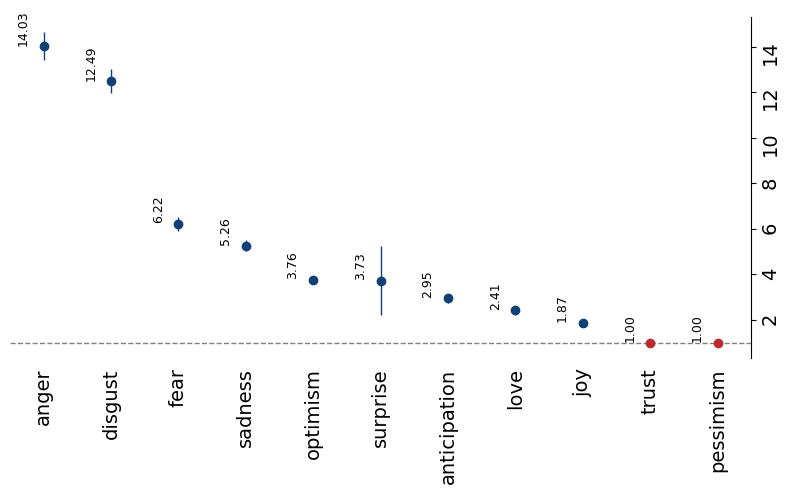

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual list of binary dimensions
dimensions_names_redux = ['joy', 'optimism', 'anticipation', 'love', 'trust',
                          'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger']

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['problem_solution'] == 0].dropna()
df_delta = df[df['problem_solution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_problem_solution.pdf')
plt.show()

In [23]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_problem_solution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_problem_solution.csv'")

Results saved to '../plots/odds_ratio_problem_solution.csv'


In [24]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_problem_solution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [25]:
odds_problem_solution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

odds_problem_solution.head()

,Emotion,Odds Ratio,Lower CI,Upper CI
0,joy,1.871609,1.794283,1.948934
1,optimism,3.758048,3.603926,3.912171
2,anticipation,2.947070,2.735636,3.158504
3,love,2.412717,2.214886,2.610549
4,trust,1.000000,-inf,inf


In [26]:
# df_no_delta = df[df['call_to_action'] == 0].dropna()
# df_delta = df[df['call_to_action'] == 1].dropna()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# y_oddsratio = []
# y_ci_OR = []
# y_ratio = []
# y_delta = []
# y_nodelta = []
# y_ci_delta= []
# y_ci_nodelta = []
# colors = []
# all_dims = dimensions_names_redux 
# for i, dim in enumerate(all_dims):
    
#     print(f'++++++++++++{dim}')
#     scores_delta = df_delta[f'{dim}_weighted'] 
#     scores_no_delta = df_no_delta[f'{dim}_weighted'] 

#     avg_delta, ci_delta = ci(scores_delta)
#     avg_no_delta, ci_no_delta = ci(scores_no_delta)
    
#     print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
#     print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

#     OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) )
#     log_OR = np.log(OR)
#     y_oddsratio.append(OR)
#     y_ratio.append((avg_delta/avg_no_delta)-1)
#     y_delta.append(avg_delta/avg_no_delta)
#     y_nodelta.append(avg_no_delta)
#     y_ci_delta.append(ci_delta/avg_no_delta)
#     y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
#     _dim_delta = int(avg_delta*len(scores_delta))
#     _no_dim_delta = len(scores_delta) - _dim_delta
#     _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
#     _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
#     _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
#     print (f'OR = {OR}')
#     print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    
#     print('>>>', 1/_dim_delta , 1/_no_dim_delta , 1/_dim_no_delta , 1/_no_dim_no_delta)
#     standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
#     print(f'STDERR = {standard_error_log_OR}')
#     ci_log_OR = 1.96 * standard_error_log_OR
#     print(f'CI LOG = {ci_log_OR}')
#     ci_log_OR_upper = log_OR + ci_log_OR
#     ci_log_OR_lower = log_OR - ci_log_OR
#     ci_OR_upper = np.power(np.e,ci_log_OR_upper)
#     ci_OR_lower = np.power(np.e,ci_log_OR_lower)
#     ci_OR = ci_OR_upper - OR
#     y_ci_OR.append(ci_OR)
    
#     print(dim, avg_delta, avg_no_delta, y_ci_OR)
#     if avg_delta > avg_no_delta:
#         clr = '#104076'
#     else:
#         clr = '#BD2B30'  
#     colors.append(clr)

# L = list(zip(y_oddsratio,y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, all_dims))
# L.sort(key=lambda x : x[0], reverse = True)
# labels_ordered = []
# y_ci_nodelta_ordered = []
# for i, l in zip(range(len(L)), L):
#     y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
#     labels_ordered.append(label)
#     y_ci_nodelta_ordered.append(err_nodelta)
    
#     #ax.plot([i], [y_odds], 'o', markersize=1, color=color)
#     ax.scatter([i], [y_odds], s=10, color=color)  
#     #ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')
#     ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
#     #ax.text(i, y_odds + 0.1, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
#     ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
# for tick in ax.get_xticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
# for tick in ax.get_yticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
    
# ax.set_xticks(range(len(labels_ordered)))
# ax.set_xticklabels(labels_ordered)
# ax.yaxis.set_ticks_position('right') 
# #ax.set_ylabel(f'Odds ratio (call-to-action)', size=18)
# ax.axhline(1, linestyle='--', linewidth=1, color='gray')
# for tick in ax.get_xticklabels():
#     tick.set_rotation(90)
# for tick in ax.get_yticklabels():
#     tick.set_rotation(90)
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# #ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.xaxis.set_ticks_position("none")
# #ax.set_xticklabels([])
# plt.tight_layout()
# plt.savefig('../plots/odds_ratio_call_to_action.pdf')

++++++++++++joy
avg. delta : 0.5480943738656987 count delta: 1653
avg. nodelta : 0.277287832684075 count nodelta: 342442
OR = 3.1611284905828354
#dim-delta=906, #nodim-delta=747, #dim-nodelta=94955, #nodim-nodelta=247487
++++++++++++optimism
avg. delta : 0.7822141560798548 count delta: 1653
avg. nodelta : 0.2556549722288738 count nodelta: 342442
OR = 10.457215838349684
#dim-delta=1293, #nodim-delta=360, #dim-nodelta=87547, #nodim-nodelta=254895
++++++++++++anticipation
avg. delta : 0.1530550514216576 count delta: 1653
avg. nodelta : 0.03567611449530139 count nodelta: 342442
OR = 4.884699598919538
#dim-delta=253, #nodim-delta=1400, #dim-nodelta=12217, #nodim-nodelta=330225
++++++++++++love
avg. delta : 0.1397459165154265 count delta: 1653
avg. nodelta : 0.031322092500335824 count nodelta: 342442
OR = 5.023900282526546
#dim-delta=231, #nodim-delta=1422, #dim-nodelta=10726, #nodim-nodelta=331716
++++++++++++trust
avg. delta : 0.0 count delta: 1653
avg. nodelta : 0.0 count nodelta: 342442


/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_54897/2978396658.py:72: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


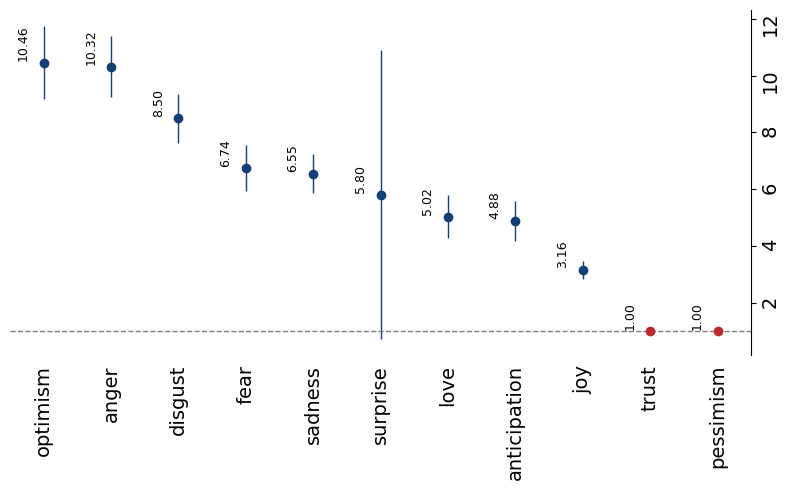

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual list of binary dimensions
dimensions_names_redux = ['joy', 'optimism', 'anticipation', 'love', 'trust',
                          'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger']

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['call_to_action'] == 0].dropna()
df_delta = df[df['call_to_action'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_call_to_action.pdf')
plt.show()

In [28]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_call_to_action.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_call_to_action.csv'")

Results saved to '../plots/odds_ratio_call_to_action.csv'


In [29]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_call_to_action_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [30]:
odds_call_to_action = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

In [31]:
# df_no_delta = df[df['intention'] == 0].dropna()
# df_delta = df[df['intention'] == 1].dropna()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# y_oddsratio = []
# y_ci_OR = []
# y_ratio = []
# y_delta = []
# y_nodelta = []
# y_ci_delta= []
# y_ci_nodelta = []
# colors = []
# all_dims = dimensions_names_redux 
# for i, dim in enumerate(all_dims):
    
#     print(f'++++++++++++{dim}')
#     scores_delta = df_delta[f'{dim}_weighted'] 
#     scores_no_delta = df_no_delta[f'{dim}_weighted'] 

#     avg_delta, ci_delta = ci(scores_delta)
#     avg_no_delta, ci_no_delta = ci(scores_no_delta)
    
#     print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
#     print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

#     OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) )
#     log_OR = np.log(OR)
#     y_oddsratio.append(OR)
#     y_ratio.append((avg_delta/avg_no_delta)-1)
#     y_delta.append(avg_delta/avg_no_delta)
#     y_nodelta.append(avg_no_delta)
#     y_ci_delta.append(ci_delta/avg_no_delta)
#     y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
#     _dim_delta = int(avg_delta*len(scores_delta))
#     _no_dim_delta = len(scores_delta) - _dim_delta
#     _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
#     _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
#     _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
#     print (f'OR = {OR}')
#     print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    
#     print('>>>', 1/_dim_delta , 1/_no_dim_delta , 1/_dim_no_delta , 1/_no_dim_no_delta)
#     standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
#     print(f'STDERR = {standard_error_log_OR}')
#     ci_log_OR = 1.96 * standard_error_log_OR
#     print(f'CI LOG = {ci_log_OR}')
#     ci_log_OR_upper = log_OR + ci_log_OR
#     ci_log_OR_lower = log_OR - ci_log_OR
#     ci_OR_upper = np.power(np.e,ci_log_OR_upper)
#     ci_OR_lower = np.power(np.e,ci_log_OR_lower)
#     ci_OR = ci_OR_upper - OR
#     y_ci_OR.append(ci_OR)
    
#     print(dim, avg_delta, avg_no_delta, y_ci_OR)
#     if avg_delta > avg_no_delta:
#         clr = '#104076'
#     else:
#         clr = '#BD2B30'  
#     colors.append(clr)

# L = list(zip(y_oddsratio,y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, all_dims))
# L.sort(key=lambda x : x[0], reverse = True)
# labels_ordered = []
# y_ci_nodelta_ordered = []
# for i, l in zip(range(len(L)), L):
#     y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
#     labels_ordered.append(label)
#     y_ci_nodelta_ordered.append(err_nodelta)
    
#     #ax.plot([i], [y_odds], 'o', markersize=1, color=color)
#     ax.scatter([i], [y_odds], s=10, color=color)  
#     #ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')
#     ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
#     #ax.text(i, y_odds + 0.1, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
#     ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# for tick in ax.get_xticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
# for tick in ax.get_yticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
    
# ax.set_xticks(range(len(labels_ordered)))
# ax.set_xticklabels(labels_ordered)
# ax.yaxis.set_ticks_position('right') 
# #ax.set_ylabel(f'Odds ratio (intention)', size=18)
# ax.axhline(1, linestyle='--', linewidth=1, color='gray')
# for tick in ax.get_xticklabels():
#     tick.set_rotation(90)
# for tick in ax.get_yticklabels():
#     tick.set_rotation(90)
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# #ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.xaxis.set_ticks_position("none")
# #ax.set_xticklabels([])
# plt.tight_layout()
# plt.savefig('../plots/odds_ratio_intention.pdf')

++++++++++++joy
avg. delta : 0.5281306715063521 count delta: 2755
avg. nodelta : 0.27657467627585397 count nodelta: 341340
OR = 2.9275271780313834
#dim-delta=1455, #nodim-delta=1300, #dim-nodelta=94406, #nodim-nodelta=246934
++++++++++++optimism
avg. delta : 0.6493647912885663 count delta: 2755
avg. nodelta : 0.2550272455616101 count nodelta: 341340
OR = 5.4098724236117475
#dim-delta=1789, #nodim-delta=966, #dim-nodelta=87051, #nodim-nodelta=254289
++++++++++++anticipation
avg. delta : 0.1484573502722323 count delta: 2755
avg. nodelta : 0.03533427081502315 count nodelta: 341340
OR = 4.759660946313472
#dim-delta=409, #nodim-delta=2346, #dim-nodelta=12061, #nodim-nodelta=329279
++++++++++++love
avg. delta : 0.120508166969147 count delta: 2755
avg. nodelta : 0.03112732173199742 count nodelta: 341340
OR = 4.264907576897866
#dim-delta=332, #nodim-delta=2423, #dim-nodelta=10625, #nodim-nodelta=330715
++++++++++++trust
avg. delta : 0.0 count delta: 2755
avg. nodelta : 0.0 count nodelta: 34134

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_54897/1893852743.py:72: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


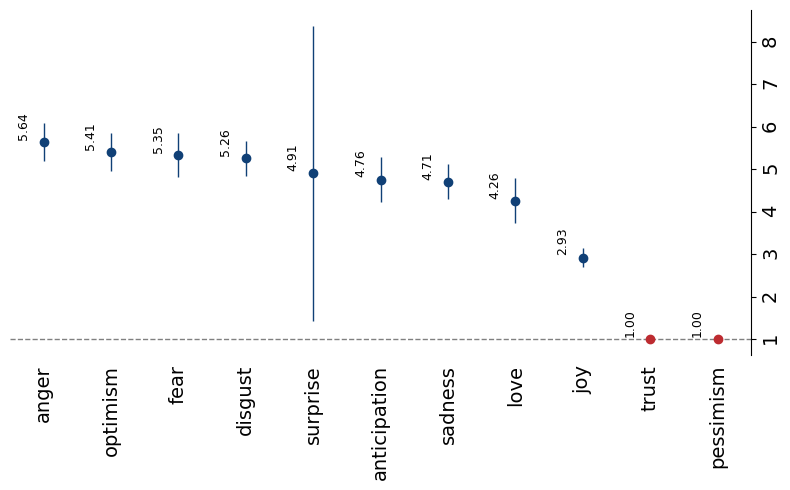

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual list of binary dimensions
dimensions_names_redux = ['joy', 'optimism', 'anticipation', 'love', 'trust',
                          'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger']

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['intention'] == 0].dropna()
df_delta = df[df['intention'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_intention.pdf')
plt.show()

In [33]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_intention.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_intention.csv'")

Results saved to '../plots/odds_ratio_intention.csv'


In [34]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_intention_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [35]:
odds_intention = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

In [36]:
# df_no_delta = df[df['execution'] == 0].dropna()
# df_delta = df[df['execution'] == 1].dropna()

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# y_oddsratio = []
# y_ci_OR = []
# y_ratio = []
# y_delta = []
# y_nodelta = []
# y_ci_delta= []
# y_ci_nodelta = []
# colors = []
# all_dims = dimensions_names_redux 
# for i, dim in enumerate(all_dims):
    
#     print(f'++++++++++++{dim}')
#     scores_delta = df_delta[f'{dim}_weighted'] 
#     scores_no_delta = df_no_delta[f'{dim}_weighted'] 

#     avg_delta, ci_delta = ci(scores_delta)
#     avg_no_delta, ci_no_delta = ci(scores_no_delta)
    
#     print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
#     print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

#     OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) )
#     log_OR = np.log(OR)
#     y_oddsratio.append(OR)
#     y_ratio.append((avg_delta/avg_no_delta)-1)
#     y_delta.append(avg_delta/avg_no_delta)
#     y_nodelta.append(avg_no_delta)
#     y_ci_delta.append(ci_delta/avg_no_delta)
#     y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
#     _dim_delta = int(avg_delta*len(scores_delta))
#     _no_dim_delta = len(scores_delta) - _dim_delta
#     _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
#     _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
#     _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
#     print (f'OR = {OR}')
#     print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    
#     print('>>>', 1/_dim_delta , 1/_no_dim_delta , 1/_dim_no_delta , 1/_no_dim_no_delta)
#     standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
#     print(f'STDERR = {standard_error_log_OR}')
#     ci_log_OR = 1.96 * standard_error_log_OR
#     print(f'CI LOG = {ci_log_OR}')
#     ci_log_OR_upper = log_OR + ci_log_OR
#     ci_log_OR_lower = log_OR - ci_log_OR
#     ci_OR_upper = np.power(np.e,ci_log_OR_upper)
#     ci_OR_lower = np.power(np.e,ci_log_OR_lower)
#     ci_OR = ci_OR_upper - OR
#     y_ci_OR.append(ci_OR)
    
#     print(dim, avg_delta, avg_no_delta, y_ci_OR)
#     if avg_delta > avg_no_delta:
#         clr = '#104076'
#     else:
#         clr = '#BD2B30'  
#     colors.append(clr)

# L = list(zip(y_oddsratio,y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, all_dims))
# L.sort(key=lambda x : x[0], reverse = True)
# labels_ordered = []
# y_ci_nodelta_ordered = []
# for i, l in zip(range(len(L)), L):
#     y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
#     labels_ordered.append(label)
#     y_ci_nodelta_ordered.append(err_nodelta)
    
#     #ax.plot([i], [y_odds], 'o', markersize=1, color=color)
#     ax.scatter([i], [y_odds], s=10, color=color)  
#     #ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')
#     ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
#     #ax.text(i, y_odds + 0.1, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)
#     ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# for tick in ax.get_xticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
# for tick in ax.get_yticklabels():
#     tick.set_fontsize(14)  # Adjust the font size as needed
    
# ax.set_xticks(range(len(labels_ordered)))
# ax.set_xticklabels(labels_ordered)
# ax.yaxis.set_ticks_position('right') 
# #ax.set_ylabel(f'Odds ratio (execution)', size=18)
# ax.axhline(1, linestyle='--', linewidth=1, color='gray')
# for tick in ax.get_xticklabels():
#     tick.set_rotation(90)
# for tick in ax.get_yticklabels():
#     tick.set_rotation(90)
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# #ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.xaxis.set_ticks_position("none")
# #ax.set_xticklabels([])
# plt.tight_layout()
# plt.savefig('../plots/odds_ratio_execution.pdf')

++++++++++++joy
avg. delta : 0.6501223348479552 count delta: 2861
avg. nodelta : 0.27547372184483376 count nodelta: 341234
OR = 4.887118073360772
#dim-delta=1860, #nodim-delta=1001, #dim-nodelta=94001, #nodim-nodelta=247233
++++++++++++optimism
avg. delta : 0.7822439706396365 count delta: 2861
avg. nodelta : 0.25379065392076994 count nodelta: 341234
OR = 10.562265863543642
#dim-delta=2238, #nodim-delta=623, #dim-nodelta=86602, #nodim-nodelta=254632
++++++++++++anticipation
avg. delta : 0.1695211464522894 count delta: 2861
avg. nodelta : 0.03512252589132384 count nodelta: 341234
OR = 5.607660705230584
#dim-delta=485, #nodim-delta=2376, #dim-nodelta=11985, #nodim-nodelta=329249
++++++++++++love
avg. delta : 0.13596644529884655 count delta: 2861
avg. nodelta : 0.030969950239425146 count nodelta: 341234
OR = 4.923771295282331
#dim-delta=389, #nodim-delta=2472, #dim-nodelta=10568, #nodim-nodelta=330666
++++++++++++trust
avg. delta : 0.0 count delta: 2861
avg. nodelta : 0.0 count nodelta: 34

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_54897/3788082427.py:72: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


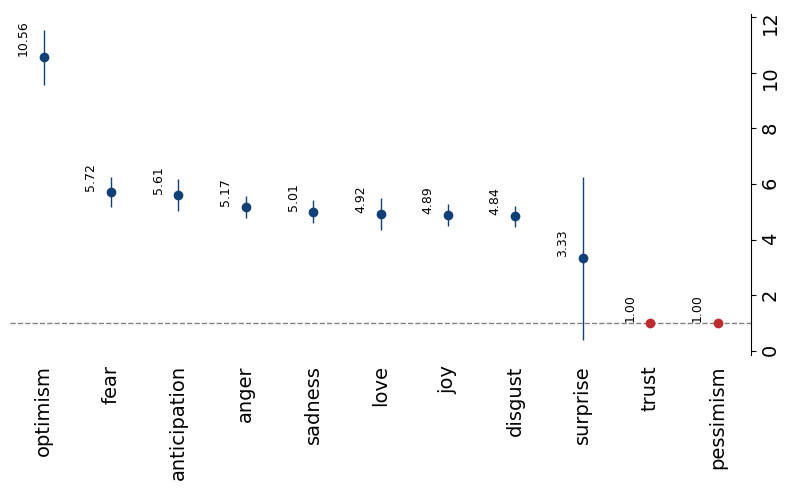

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual list of binary dimensions
dimensions_names_redux = ['joy', 'optimism', 'anticipation', 'love', 'trust',
                          'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger']

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['execution'] == 0].dropna()
df_delta = df[df['execution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_execution.pdf')
plt.show()

In [38]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_execution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_execution.csv'")

Results saved to '../plots/odds_ratio_execution.csv'


In [39]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_execution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [40]:
odds_execution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

Matrix of significant odds ratios

In [41]:
odds_dfs = {
    'Problem-Solution': odds_problem_solution,
    'Call-to-Action': odds_call_to_action,
    'Intention': odds_intention,
    'Execution': odds_execution
}
odds_matrix = pd.DataFrame({'Emotion': odds_problem_solution['Emotion']})

for level, df in odds_dfs.items():
    df_filtered = df[(df['Lower CI'] > 1) | (df['Upper CI'] < 1)]  # Keep only significant odds ratios
    df_filtered = df_filtered[['Emotion', 'Odds Ratio']].rename(columns={'Odds Ratio': level})
    odds_matrix = odds_matrix.merge(df_filtered, on='Emotion', how='left')

odds_matrix
odds_matrix.set_index('Emotion', inplace=True)
odds_matrix

,Problem-Solution,Call-to-Action,Intention,Execution
Emotion,,,,
joy,1.871609,3.161128,2.927527,4.887118
optimism,3.758048,10.457216,5.409872,10.562266
anticipation,2.947070,4.884700,4.759661,5.607661
love,2.412717,5.023900,4.264908,4.923771
trust,NaN,NaN,NaN,NaN
surprise,3.729606,NaN,4.905982,NaN
sadness,5.261271,6.549822,4.711609,5.012852
disgust,12.494234,8.498835,5.257846,4.839715
fear,6.218595,6.744770,5.346121,5.724622


In [42]:
min_value = odds_matrix.min().min()
max_value = odds_matrix.max().max()

print(f"Smallest value: {min_value}")
print(f"Largest value: {max_value}")

Smallest value: 1.8716088150925805
Largest value: 14.033876320894114


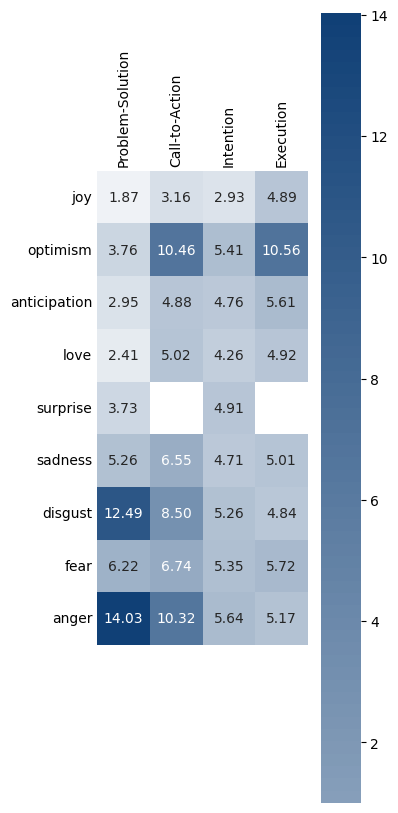

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Filter out rows where all values are NaN
odds_matrix_significant = odds_matrix.dropna(how='all')

# Check if 'Emotion' is the index, if not, set it as the index
if 'Emotion' in odds_matrix_significant.columns:
    odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# Ensure all data is numeric
odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# Define a custom diverging colormap with 1.00 centered at white
colors = ["#BD2B30", "white", "#104076"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 1.0
divnorm = mcolors.TwoSlopeNorm(vcenter=1.0)

# Create the heatmap
plt.figure(figsize=(4, 10))
ax = sns.heatmap(
    odds_matrix_significant, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    #cbar_kws={'label': 'Odds Ratio'},
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# # Set ticks and labels on colormap from 0.25 to 4 with steps of 0.25
# cbar = ax.collections[0].colorbar
# cbar.set_ticks(np.arange(0.25, 4.25, 0.25))
# cbar.set_ticklabels(np.arange(0.25, 4.25, 0.25).round(2))  # Set tick labels

# Move xticks to top
ax.xaxis.set_ticks_position('top')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated



# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

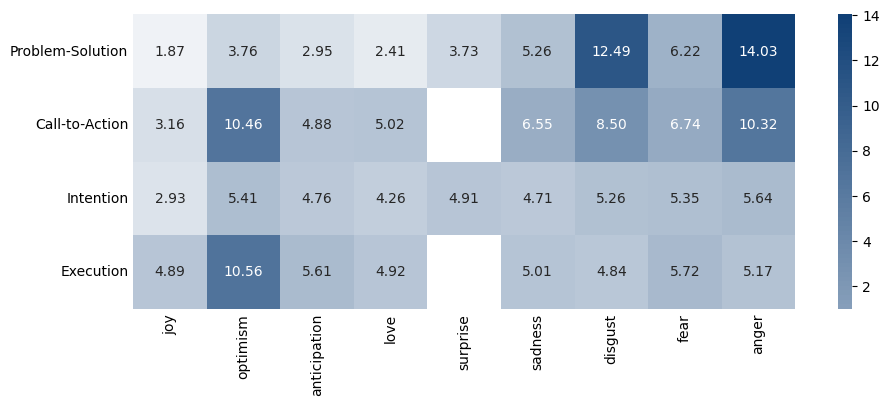

In [44]:
# Transpose the data to switch x and y axes
odds_matrix_significant_transposed = odds_matrix_significant.transpose()

colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red

# Create the heatmap with transposed data
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')


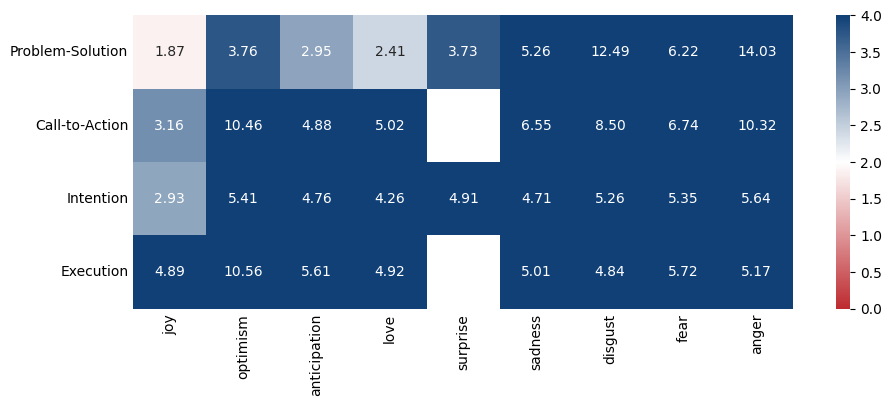

In [45]:
# Define a custom diverging colormap with 1.00 centered at white, but switch blue and red
colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 2.0, while keeping 1.0 as white
divnorm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.0, vmax=4)

# Create the heatmap with transposed data and updated colormap
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Set center of colormap to 2.0
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

In [46]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for -3, white for 1, blue for 5
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Define the custom normalization with the vmin and vmax parameters
# norm = mcolors.Normalize(vmin=0, vmax=5)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()

In [47]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import numpy as np

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for the smallest value, white for 1, blue for the largest value
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Get the smallest and largest values in the matrix
# vmin = odds_matrix_significant.min().min()  # smallest value in the dataframe
# vmax = odds_matrix_significant.max().max()  # largest value in the dataframe

# # Define custom boundaries and normalization
# boundaries = [vmin, 1, vmax]  # Define custom bins for color mapping
# norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization with boundaries
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()


#### Frequent dimension pairs in post-reply pairs

##### Preparation

In [48]:
#df_paired = D.copy()
df_posts = D[['post_id', 'vader_sentiment_post','score_post','number_of_words_post','log_number_of_words_post','support_post','knowledge_post','conflict_post','power_post','similarity_post','fun_post','status_post','trust_post','identity_post','romance_post','sentiment_pos_post','sentiment_neg_post','support_weighted_post','knowledge_weighted_post','conflict_weighted_post','power_weighted_post','similarity_weighted_post','fun_weighted_post','status_weighted_post','trust_weighted_post','identity_weighted_post','romance_weighted_post','sentiment_pos_weighted_post','sentiment_neg_weighted_post','num_links','length','log_num_links','log_length','links_per_length']]
df_posts.columns = ['post_id', 'vader_sentiment','score_post','number_of_words_post','log_number_of_words_post','support','knowledge','conflict','power','similarity','fun','status','trust','identity','romance','sentiment_pos','sentiment_neg','support_weighted','knowledge_weighted','conflict_weighted','power_weighted','similarity_weighted','fun_weighted','status_weighted','trust_weighted','identity_weighted','romance_weighted','sentiment_pos_weighted','sentiment_neg_weighted','num_links','length','log_num_links','log_length','links_per_length']
df_posts = df_posts.drop_duplicates(subset=['post_id'])
len(df_posts)

KeyError: "None of [Index(['post_id', 'vader_sentiment_post', 'score_post', 'number_of_words_post',\n       'log_number_of_words_post', 'support_post', 'knowledge_post',\n       'conflict_post', 'power_post', 'similarity_post', 'fun_post',\n       'status_post', 'trust_post', 'identity_post', 'romance_post',\n       'sentiment_pos_post', 'sentiment_neg_post', 'support_weighted_post',\n       'knowledge_weighted_post', 'conflict_weighted_post',\n       'power_weighted_post', 'similarity_weighted_post', 'fun_weighted_post',\n       'status_weighted_post', 'trust_weighted_post', 'identity_weighted_post',\n       'romance_weighted_post', 'sentiment_pos_weighted_post',\n       'sentiment_neg_weighted_post', 'num_links', 'length', 'log_num_links',\n       'log_length', 'links_per_length'],\n      dtype='object')] are in the [columns]"

In [ ]:
df_comments_shuffled = df_comments.copy(deep=True)
print(len(df_comments_shuffled))
df_comments_shuffled['post_id'] = np.random.permutation(df_comments_shuffled['post_id'].values)
print(len(df_comments_shuffled))
#create shuffled versions of comments and join it with pots
df_paired_shuffled = pd.merge(df_comments_shuffled, df_posts, left_on='post_id', right_on='post_id', how='inner', suffixes=('_comment','_post'))
print(len(df_paired_shuffled))

#### Frequent dimension pairs in post-reply pairs

In [ ]:
df_paired = D.copy()
df_paired = df_paired[(df_paired['has_delta'] == True) | (df_paired['has_answer_by_op'] == True)] 
df_paired_shuffled = df_paired_shuffled[(df_paired_shuffled['has_delta'] == True) | (df_paired_shuffled['has_answer_by_op'] == True)] 

In [ ]:
df_paired_shuffled.head()

In [ ]:
for t in ['post', 'comment']:
    df_paired[f'nodimensions_{t}'] = sum([df_paired[f'{d}_{t}'] for d in dimensions_names_redux])
    df_paired[f'nodimensions_{t}'] = df_paired[f'nodimensions_{t}'].apply(lambda x : 0 if x>0 else 1)
    df_paired[f'nodimensions_weighted_{t}'] = df_paired[f'nodimensions_{t}']
    
    df_paired[f'anydimensions_{t}'] = sum([df_paired[f'{d}_{t}'] for d in dimensions_names_redux])
    df_paired[f'anydimensions_{t}'] = df_paired[f'anydimensions_{t}'].apply(lambda x : 1 if x>0 else 0)
    df_paired[f'anydimensions_weighted_{t}'] = df_paired[f'anydimensions_{t}']

    if t == 'post':
        log_lengths = df_paired[df_paired[f'nodimensions_{t}'] == 1]['log_number_of_words_post']
        avg = np.mean(log_lengths)
        stdev = np.std(log_lengths)
        df_paired[f'nodimensions_weighted_{t}'] = df_paired['log_number_of_words_post'].apply(lambda x: standardized_dimension_score(x,avg,stdev)) * df_paired[f'nodimensions_{t}']
        df_paired[f'anydimensions_weighted_{t}'] = np.sum([df_paired[f'{d}_weighted_{t}'] for d in dimensions_names_redux])

    df_paired_shuffled[f'nodimensions_{t}'] = sum([df_paired_shuffled[f'{d}_{t}'] for d in dimensions_names_redux])
    df_paired_shuffled[f'nodimensions_{t}'] = df_paired_shuffled[f'nodimensions_{t}'].apply(lambda x : 0 if x>0 else 1)
    df_paired_shuffled[f'nodimensions_weighted_{t}'] = df_paired_shuffled[f'nodimensions_{t}']

##### Delta vs. no-Delta in posts

In [ ]:
field_selection = ['post_id', 'comment_id', 'has_delta', 'has_answer_by_op'] 
field_selection += [d+'_post' for d in dimensions_names]
field_selection += [d+'_weighted_post' for d in dimensions_names]
field_selection += ['sentiment_pos_weighted_post', 'sentiment_neg_weighted_post']
field_selection += ['nodimensions_comment', 'nodimensions_post', 'nodimensions_weighted_comment', 'nodimensions_weighted_post']
field_selection += ['anydimensions_comment', 'anydimensions_post', 'anydimensions_weighted_comment', 'anydimensions_weighted_post']
df_posts_delta_nondelta = df_paired[field_selection].drop_duplicates(subset=['post_id', 'comment_id', 'has_delta'])  
#df_posts_delta_nondelta['number_of_words'] = df_posts_delta_nondelta['selftext'].apply(lambda x : len(x.split()))
print(len(df_posts_delta_nondelta))
df_posts_delta_nondelta.head()

In [ ]:
df_posts_delta = df_posts_delta_nondelta[df_posts_delta_nondelta['has_delta'] == True].drop_duplicates().dropna()
print(len(df_posts_delta))
df_posts_delta.head()

In [ ]:
df_posts_nodelta = df_posts_delta_nondelta[~df_posts_delta_nondelta['post_id'].isin(df_posts_delta['post_id'])].drop_duplicates().dropna()
print(len(df_posts_nodelta))
df_posts_nodelta.head()

In [ ]:
#WEIGHT DISCOUNTED VERSION
fig, ax = plt.subplots(1, 1, figsize=(8,5))

plotfile = open('PLOTFILE_odds_ratios_posts_hasanswer.csv', 'wt', encoding='utf8')
plotfile.write('dimension,odds_ratio,ci_95\n')
y_oddsratio = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta= []
y_ci_nodelta = []
y_ci_OR = []
colors = []
#all_dims = dimensions_names + additional_dims_names_binarized
for i, dim in enumerate(dimensions_names_redux + ['sentiment_pos', 'sentiment_neg', 'nodimensions']):
    scores_delta = df_posts_delta[f'{dim}_weighted_post'] 
    scores_no_delta = df_posts_nodelta[f'{dim}_weighted_post'] 
    
    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)
    OR = (avg_delta / (1 - avg_delta)) / ( avg_no_delta / (1-avg_no_delta) ) 
    log_OR = np.log(OR)
    y_oddsratio.append( OR )
    y_ratio.append((avg_delta/avg_no_delta)-1)
    y_delta.append(avg_delta/avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta/avg_no_delta)
    y_ci_nodelta.append(ci_no_delta/avg_no_delta)
    
    
    _dim_delta = int(avg_delta*len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta*len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta
    _all_cases = _dim_delta + _no_dim_delta + _dim_no_delta + _no_dim_no_delta
    
    standard_error_log_OR = np.sqrt(1/_dim_delta + 1/_no_dim_delta + 1/_dim_no_delta + 1/_no_dim_no_delta)
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_log_OR_upper = log_OR + ci_log_OR
    ci_log_OR_lower = log_OR - ci_log_OR
    ci_OR_upper = np.power(np.e,ci_log_OR_upper)
    ci_OR_lower = np.power(np.e,ci_log_OR_lower)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)
    
    plotfile.write(f'{dim},{OR},{ci_OR}\n')

    print(dim, avg_delta, avg_no_delta, ci_delta, ci_no_delta)
    print('     ', _dim_delta,_no_dim_delta,_dim_no_delta , _no_dim_no_delta, 
          _all_cases, len(scores_delta), len(scores_no_delta), len(scores_delta) + len(scores_no_delta))
    if avg_delta > avg_no_delta:
        clr = 'b'
    else:
        clr = 'r'
    colors.append(clr)

L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux + [ 'sentiment_pos', 'sentiment_neg', 'nodimensions', 'anydimensions']))
L.sort(key=lambda x : x[0], reverse = True)
labels_ordered = []
y_ci_nodelta_ordered = []
for i, l in zip(range(len(L)), L):
    y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label = l
    labels_ordered.append(label)
    y_ci_nodelta_ordered.append(err_nodelta)
    ax.plot([i], [y_odds],'o', markersize=2, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt=f'{color}-')

ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered)
ax.set_ylabel(f'odds ratio', size=18)
ax.axhline(1, linestyle='--', linewidth=1, color='gray')
for tick in ax.get_xticklabels():
    tick.set_rotation(90)
plt.tight_layout()
plotfile.close()

##### Comparison with randomized

In [ ]:
dimensions_names_extended = dimensions_names_redux + ['nodimensions']#, 'sentiment_pos', 'sentiment_neg']

In [ ]:
has_answer_filter=False #HAS ANSWER FILTER

for apply_weighting in ['comment']:#, 'comment', 'both']: #None
    print(f'weighting = {apply_weighting}')
    matrices = {True:None, False:None} #true/false refer to whether they have delta or not
    matrices_shuffled = {True:None, False:None} #true/false refer to whether they have delta or not
    matrices_discounted = {True:None, False:None} #true/false refer to whether they have delta or not

    for is_delta in [True, False]: #loops over delta and no-delta
        print('------Delta = ', is_delta)
        dicts = {'normal':{}, 'shuffled':{}}
        for d, data_type in zip([df_paired, df_paired_shuffled], ['normal', 'shuffled']): #loops over normal and shuffled
            print('---Type = ', data_type)

            #compare delta vs. nodelta
            d = d[d['has_delta'] == is_delta]
            
            if has_answer_filter:
                d = d[(d['has_delta'] == True) | (d['has_answer_by_op'] == True)] 

            print('>', len(d))
            #d = d[(d['number_of_words'] > 0) & (d['number_of_words_post'] > 0)]
            d = d[d['number_of_words'] > 0]
            print('>>', len(d))
            d = d[d['number_of_words_post'] > 0]
            print('>>>', len(d))
            
            d = d [['number_of_words', 'number_of_words_post'] + 
                   [f'{dim}_post' for dim in dimensions_names_extended] +
                   [f'{dim}_comment' for dim in dimensions_names_extended] +
                   [f'{dim}_weighted_post' for dim in dimensions_names_extended] +
                   [f'{dim}_weighted_comment' for dim in dimensions_names_extended]
                  ]
            
            d = d.dropna()

            tot_pairs = len(d)
            print(is_delta, data_type, tot_pairs)
            dim2matches = dicts[data_type]
            for dim1 in dimensions_names_extended: #looks at dim1 in posts
                dim2matches[dim1] = {}
                for dim2 in dimensions_names_extended: #looks at dim2 in comments 
                    d['in_post'] = d[f'{dim1}_post'].apply(bool) # dim1 in post
                    d['in_comment'] = d[f'{dim2}_comment'].apply(bool) #dim2 in comments
                    d['in_both'] = d['in_comment'] & d['in_post'] 
                    d['in_post'] = d['in_post'].apply(int)
                    d['in_comment'] = d['in_comment'].apply(int)
                    d['in_both'] = d['in_both'].apply(int)
                    
                    if apply_weighting is None:
                        p_dimpost_and_dimcomment = sum(d['in_both'])/tot_pairs #P(dim1, dim2)
                        p_dimcomment_given_dimpost = sum(d['in_both'])/sum(d['in_post']) #P(dim2 | dim1)
                    elif apply_weighting == 'comment':
                        d['in_both_weighted'] = d[f'{dim2}_weighted_comment'] * d['in_both']
                        p_dimpost_and_dimcomment = (sum(d['in_both_weighted']), tot_pairs) #P(dim1, dim2)
                        p_dimcomment_given_dimpost = (sum(d['in_both_weighted']) , sum(d['in_post'])) #P(dim2 | dim1)
                    elif apply_weighting == 'both':
                        p_dimpost_and_dimcomment = sum(d['in_both_weighted'])/sum(d['inverse_post_length']) #P(dim1, dim2)
                        p_dimcomment_given_dimpost = sum(d['in_both_weighted'])/sum(d['in_post_weighted']) #P(dim2 | dim1)

                    dim2matches[dim1][dim2] = (p_dimpost_and_dimcomment, p_dimcomment_given_dimpost)#p_dimcomment_given_dimpost #p_dimpost_and_dimcomment # p_dimcomment_given_dimpost
        del(d)


        matrix = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] #empty matrix
        for i,dim1 in enumerate(dimensions_names_extended):
            for j,dim2 in enumerate(dimensions_names_extended):
                v = dicts['normal'][dim1][dim2] #bare probability
                matrix[i][j] = v
        matrices[is_delta] = matrix

        matrix_shuffled = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] #empty matrix
        for i,dim1 in enumerate(dimensions_names_extended):
            for j,dim2 in enumerate(dimensions_names_extended):
                v = dicts['shuffled'][dim1][dim2] #shuffled probability
                matrix_shuffled[i][j] = v
        matrices_shuffled[is_delta] = matrix_shuffled

        matrix_discounted = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] #empty matrix
        for i,dim1 in enumerate(dimensions_names_extended):
            for j,dim2 in enumerate(dimensions_names_extended):
                p_joint_pair, p_cond_pair = dicts['normal'][dim1][dim2]
                p_joint = p_joint_pair[0]/p_joint_pair[1]
                p_cond = p_cond_pair[0]/p_cond_pair[1]
                p_joint_shuffled_pair, p_cond_shuffled_pair = dicts['shuffled'][dim1][dim2]
                p_joint_shuffled = p_joint_shuffled_pair[0]/p_joint_shuffled_pair[1]
                p_cond_shuffled = p_cond_shuffled_pair[0]/p_cond_shuffled_pair[1]
                
                
                stderr_log_joint_pval = np.sqrt(1/p_joint_pair[0] + 1/p_joint_pair[1] + 1/p_joint_shuffled_pair[0] + 1/p_joint_shuffled_pair[1])

                
                or_joint = (p_joint / (1-p_joint)) / (p_joint_shuffled / (1-p_joint_shuffled))
                or_cond = (p_cond / (1-p_cond)) / (p_cond_shuffled / (1-p_cond_shuffled))
                
                print(or_joint, or_cond,stderr_log_joint_pval)                
                
                matrix_discounted[i][j] = (or_joint, or_cond, stderr_log_joint_pval)
        matrices_discounted[is_delta] = matrix_discounted

    if apply_weighting is None:
        weight_suffix = 'unweighted'
    else:
        weight_suffix = f'weighted-{apply_weighting}'
    if has_answer_filter:
        suffix = '_hasanswer'
    else:
        suffix = ''

In [ ]:
import scipy.stats as st
suffix = ''#, '_hasanswer' #'_condprob_noshuffle' #'_alignment_comparison' '_hasanswer'
p_type = 'cond' #'cond' #'joint'
transformation = '_discounted' #'_shuffled' #'_discounted', #''
for weight in ['weighted-comment']:#['unweighted', 'weighted-comment', 'weighted-both']:
    fname=f'matrix_NEW_{weight}{transformation}{suffix}'
    print(fname)
    matrices = pickle.load(open(fname, 'rb'))
    matrices
    M = {True:None, False:None}
    for is_delta in matrices:
        matrix = matrices[is_delta]
        matrix_joint = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] 
        matrix_cond = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] 
        matrix_stderr = [[0 for d in dimensions_names_extended] for d in dimensions_names_extended] 
        for i,dim1 in enumerate(dimensions_names_extended):
            for j,dim2 in enumerate(dimensions_names_extended):
                p_joint = matrix[i][j][0]
                p_cond = matrix[i][j][1]
                stderr = matrix[i][j][2]
                matrix_joint[i][j] = p_joint
                matrix_cond[i][j] = p_cond
                matrix_stderr[i][j] = stderr
        if p_type == 'cond':
            matrix = matrix_cond
        elif p_type == 'joint':
            matrix = matrix_joint

        M[is_delta] = (matrix,matrix_stderr)

        fig = plt.figure(figsize=(8,8))
        ax = fig.add_subplot(111)
        cmap = matplotlib.cm.get_cmap('coolwarm_r')#coolwarm_r #Blues
        #norm=mcolors.Normalize())
        cax = ax.matshow(matrix, interpolation='nearest', cmap=cmap, 
                         norm=mcolors.TwoSlopeNorm(vcenter=1.0))
        #cmap = matplotlib.cm.get_cmap('Blues')
        #cax = ax.matshow(matrix, interpolation='nearest', cmap=cmap)
        ax.set_xticks(range(0,len(dimensions_names_extended)))
        ax.set_yticks(range(0,len(dimensions_names_extended)))
        ax.set_xticklabels(dimensions_names_extended)
        ax.set_yticklabels(dimensions_names_extended)
        fig.colorbar(cax, fraction=0.046, pad=0.04)
        ax.set_ylabel('Post')
        ax.set_xlabel('Comment')
        ax.xaxis.set_label_position('top')
        for tick in ax.get_xticklabels():
            tick.set_rotation(90)

        #add labels
        for i,dim1 in enumerate(dimensions_names_extended):
            for j,dim2 in enumerate(dimensions_names_extended):
                c = matrix[i][j]
                ax.text(j, i, f'{c:.2f}', va='center', ha='center')

        plt.tight_layout()
        if is_delta: 
            plt.savefig(f'figs/matrix_{p_type}_{weight}_delta{transformation}.pdf', transparent=False, dpi=400)
        else:
            plt.savefig(f'figs/matrix_{p_type}_{weight}_nodelta{transformation}.pdf', transparent=False, dpi=400)

    diff_matrix = [[0 for d in dimensions_names_extended] for d in  dimensions_names_extended] #empty matrix
    pval_matrix = [[0 for d in dimensions_names_extended] for d in  dimensions_names_extended] #empty matrix
    for i,dim1 in enumerate(dimensions_names_extended):
        for j,dim2 in enumerate(dimensions_names_extended):
            difference = M[True][0][i][j] - M[False][0][i][j]
            errors = np.sqrt(M[True][1][i][j]**2 + M[False][1][i][j]**2)
            Z = difference/errors
            #pval = st.norm.cdf(Z)
            pval = scipy.stats.norm.sf(abs(Z))
            if pval <= 0.01:
                diff_matrix[i][j] = difference
            else:
                diff_matrix[i][j] = 0#difference

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    cmap = matplotlib.cm.get_cmap('PiYG')
    cax = ax.matshow(diff_matrix, interpolation='nearest', cmap=cmap, 
                     norm=mcolors.TwoSlopeNorm(vcenter=0.0))
    #cmap = matplotlib.cm.get_cmap('Blues')
    #cax = ax.matshow(matrix, interpolation='nearest', cmap=cmap)
    ax.set_xticks(range(0,len(dimensions_names_extended)))
    ax.set_yticks(range(0,len(dimensions_names_extended)))
    ax.set_xticklabels(dimensions_names_extended)
    ax.set_yticklabels(dimensions_names_extended)
    fig.colorbar(cax,fraction=0.046, pad=0.04)
    ax.set_ylabel('Post')
    ax.set_xlabel('Comment')
    ax.xaxis.set_label_position('top')
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)

    #add labels
    for i,dim1 in enumerate(dimensions_names_extended):
        for j,dim2 in enumerate(dimensions_names_extended):
            c = diff_matrix[i][j]
            ax.text(j, i, f'{c:.2f}', va='center', ha='center')

    plt.tight_layout()